In [2]:
import time
from matplotlib import pyplot as plt
import numpy as np

In [17]:
from Bse_Explicit.bse_analytical import bse_analytical
from G_Brownian_Motion.Geometric_BM import monte_carlo_call_put

S0 = 274.80
K = 275.00
r = 0.0375
sigma = 0.1730
T = 0.0548
numofPaths = 100000
timeSteps = 125
rng=np.random.default_rng(42)

time_taken = np.zeros(7)

gridSize = [ 65536, 262144, 1048576, 2048576]

times = []
prices = []

for dS in gridSize:
    start = time.time()
    results = monte_carlo_call_put(
        S0=S0,
        K=K,
        r=r,
        sigma=sigma,
        T=T,
        numofPaths=dS,
        timeSteps=252,
        rng=np.random.default_rng(42),
    )
    end = time.time() - start
    prices.append(float(results['call']['price']))
    times.append(float(end))

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].plot(gridSize, times, marker="o", label="Python")
axes[0].legend()
axes[0].set_xlabel("Number of Monte Carlo paths")
axes[0].set_ylabel("Time taken (seconds)")
axes[0].set_title("Runtime vs number of Monte Carlo paths")
axes[0].grid(True)


prices = np.array(prices)
bs = float(bse_analytical(sigma, r, T, K, S0))

MemoryError: Unable to allocate 1.97 GiB for an array with shape (252, 1048576) and data type float64

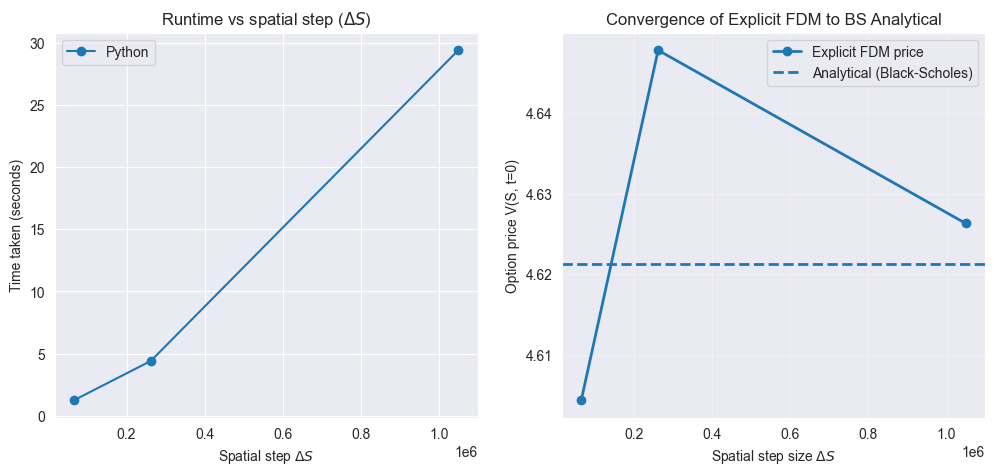

In [14]:

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].plot(gridSize, times, marker="o", label="Python")
axes[0].legend()
axes[0].set_xlabel(r"Spatial step $\Delta S$")
axes[0].set_ylabel("Time taken (seconds)")
axes[0].set_title(r"Runtime vs spatial step ($\Delta S$)")
axes[0].grid(True)



axes[1].plot(gridSize, prices, marker="o", linewidth=2, label="Explicit FDM price")
axes[1].axhline(bs, linestyle="--", linewidth=2, label="Analytical (Black-Scholes)")
axes[1].set_xlabel(r"Spatial step size $\Delta S$")
axes[1].set_ylabel("Option price V(S, t=0)")
axes[1].set_title("Convergence of Explicit FDM to BS Analytical")
axes[1].grid(True, alpha=0.3)
axes[1].legend()
